# MAI 600 — Final Project

## Local Hybrid Assistant for Customer Support Ticket Triage

A hybrid system: **retrieval supplies the organisation's routing knowledge, a locally
served small language model writes the triage.** Everything runs on the analyst's own
machine — no hosted API, no ticket text leaving the laptop.

A support ticket arrives. The system retrieves similar past cases from a knowledge base
built out of the support team's own resolution history, then asks the model for a routing
queue, a ticket type, a priority, a draft first response, and citations to the sources it
used.

### Three system versions, same tickets, same model

| Version | Retrieval | Queue choice | What it is for |
|---|---|---|---|
| V0 — baseline | none | free | how far the model gets with no organisational knowledge |
| V1 — RAG, open choice | MiniLM + FAISS | free | the Module 7 prototype |
| V2 — RAG, constrained | MiniLM + FAISS | restricted to the retrieved queues | the Module 8 improvement |

Because all three run the same model, retrieval and prompt design are the only variables.
V1 against V2 isolates the Module 8 change specifically.

A **majority-class floor** is computed alongside them — answer the most frequent label
every time, no model involved. Module 7 found that two of the three predicted fields did
not clear that floor, which is the problem this version sets out to address.

Run the cells top to bottom. Ollama must be running before the generation section.

## 1. Configuration and project folders

In [1]:
# ============================================================
# 1. Configuration
# ============================================================

import os, json, time, re, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

# Resolve the project root whether the notebook is launched from the root or
# from notebooks/ (nbconvert runs with cwd = the notebook's own folder).
ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
DATA, RESULTS, IMAGES = ROOT / "data", ROOT / "results", ROOT / "images"
for d in (DATA, RESULTS, IMAGES):
    d.mkdir(parents=True, exist_ok=True)

CSV_PATH    = DATA / "dataset-tickets-multi-lang-4-20k.csv"
EMBED_MODEL = "all-MiniLM-L6-v2"
OLLAMA_URL  = "http://localhost:11434/api/generate"

MODEL = "llama3.2:3b"   # one model for every version: retrieval is the only variable

CASES_PER_QUEUE = 5    # held-out test tickets per queue (10 queues -> 50 cases)
CASES_PER_DOC   = 200  # past tickets per queue document (was 14 in Module 7)
TOP_K           = 5    # chunks retrieved per query
DEDUP_THRESHOLD = 0.90 # cosine similarity above which two tickets are the same ticket
SEED         = 42

print("Project root:", ROOT)
print("Dataset     :", CSV_PATH.name)
print("Model       :", MODEL)

Project root: /Users/juampa/Documents/AtlantisUniversity/Master/MAI600/finalProject
Dataset     : dataset-tickets-multi-lang-4-20k.csv
Model       : llama3.2:3b


## 2. Load the dataset and keep the English tickets

In [2]:
# ============================================================
# 2. Load data
# ============================================================

df = pd.read_csv(CSV_PATH)
print("Total rows:", len(df))
print("Languages :", df["language"].value_counts().to_dict())

# English only. German rows would pollute the embeddings and the triage has to
# be written in English.
df = df[df["language"] == "en"].copy()
df = df.dropna(subset=["subject", "body", "answer", "queue", "type", "priority"])
df = df.reset_index(drop=True)

print("Usable English tickets:", len(df))
print()
print("Queues:")
print(df["queue"].value_counts())

Total rows: 20000
Languages : {'en': 11923, 'de': 8077}
Usable English tickets: 10888

Queues:
queue
Technical Support                  3119
Product Support                    2034
Customer Service                   1710
IT Support                         1274
Billing and Payments               1193
Returns and Exchanges               530
Service Outages and Maintenance     415
Sales and Pre-Sales                 282
Human Resources                     183
General Inquiry                     148
Name: count, dtype: int64


## 3. Build the knowledge base: one document per queue

The retrieval corpus is **10 documents, one per support queue**. Each document is
assembled from real agent answers written for tickets in that queue, so the knowledge
base is grounded in how the support team actually resolves things — nothing is invented.

This mirrors how a real help desk stores knowledge (a playbook per team) and it makes
citations readable: the model cites `DOC-003 / Billing and Payments`, not an opaque
ticket id.

In [3]:
# ============================================================
# 3A. De-duplicate the corpus, then split
# ============================================================

# This dataset is synthetic and was generated by paraphrasing templates, so it contains
# large families of near-identical tickets. On the raw data the median cosine similarity
# between a test ticket and its nearest neighbour is 0.906 -- the same ticket reworded,
# not two customers with a similar problem.
#
# That silently invalidates the evaluation. Retrieving over the raw corpus scores 0.68 on
# queue prediction, which looks like a working system and is actually the model finding a
# paraphrase of the test ticket and copying its label. Excluding neighbours above 0.85
# collapses that to 0.12.
#
# So the corpus is de-duplicated before anything else touches it: one representative per
# near-duplicate family. The verification cell below then asserts that no test ticket has
# a knowledge-base neighbour above the threshold.

import gc
from sentence_transformers import SentenceTransformer
import faiss

# PyTorch and FAISS each ship their own OpenMP runtime. On Apple Silicon, calling into
# FAISS after torch has run segfaults the process -- silently, as a dead kernel with no
# traceback. Pinning FAISS to a single thread avoids the clash. At this corpus size the
# cost is nil; the index holds ten thousand vectors, not ten million.
faiss.omp_set_num_threads(1)

# One embedder for the whole notebook. Loading a second copy alongside torch and FAISS
# was enough to exhaust the kernel on the full corpus.
embedder = SentenceTransformer(EMBED_MODEL)

all_text = (df["subject"].astype(str).str.strip() + ". " +
            df["body"].astype(str).str.strip()).tolist()
emb_all = embedder.encode(all_text, convert_to_numpy=True,
                          show_progress_bar=False, batch_size=64).astype("float32")
faiss.normalize_L2(emb_all)

dedup_index = faiss.IndexFlatIP(emb_all.shape[1])
dedup_index.add(emb_all)

# Searched in blocks: one all-pairs call over the full corpus is what killed the kernel.
keep = np.ones(len(df), dtype=bool)
BLOCK = 512
for start in range(0, len(df), BLOCK):
    stop = min(start + BLOCK, len(df))
    sim, nbr = dedup_index.search(emb_all[start:stop], 30)
    for row in range(stop - start):
        a = start + row
        if not keep[a]:
            continue
        for c in range(1, 30):
            b = int(nbr[row, c])
            if sim[row, c] >= DEDUP_THRESHOLD and b != a and keep[b]:
                keep[b] = False

del dedup_index
gc.collect()

print(f"English tickets              : {len(df)}")
print(f"After de-duplication @{DEDUP_THRESHOLD}   : {keep.sum()} "
      f"({100 * keep.sum() / len(df):.1f}% kept)")

df = df[keep].reset_index(drop=True)
emb_all = emb_all[keep]

# Stratified split: the same number of test tickets from every queue.
rng = np.random.RandomState(SEED)
test_idx = list(df.groupby("queue", group_keys=False)
                  .apply(lambda g: g.sample(min(CASES_PER_QUEUE, len(g)),
                                            random_state=SEED))
                  .index)

test_df = df.loc[test_idx].reset_index(drop=True)
kb_pool = df.drop(index=test_idx).reset_index(drop=True)

print(f"\nHeld-out test tickets        : {len(test_df)}")
print(f"Knowledge base pool          : {len(kb_pool)}")
print()
print("Test tickets per queue:")
print(test_df["queue"].value_counts().to_string())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

English tickets              : 10888
After de-duplication @0.9   : 7163 (65.8% kept)

Held-out test tickets        : 50
Knowledge base pool          : 7113

Test tickets per queue:
queue
Billing and Payments               5
Customer Service                   5
General Inquiry                    5
Human Resources                    5
IT Support                         5
Product Support                    5
Returns and Exchanges              5
Sales and Pre-Sales                5
Service Outages and Maintenance    5
Technical Support                  5


In [4]:
# ============================================================
# 3B. Assemble one document per queue from real agent answers
# ============================================================

QUEUES = sorted(df["queue"].unique())

documents = []
for i, q in enumerate(QUEUES, start=1):
    pool = kb_pool[kb_pool["queue"] == q]
    # Balanced across queues on purpose. The queue distribution in the raw data is
    # heavily skewed -- Technical Support carries roughly twenty times the volume of
    # General Inquiry -- and an unbalanced knowledge base would bias the retrieval vote
    # toward whichever queue simply contributed more chunks.
    picked = pool.sample(min(CASES_PER_DOC, len(pool)), random_state=SEED)

    cases = []
    for _, r in picked.iterrows():
        cases.append({
            # What gets embedded: the CUSTOMER's description of the problem.
            # Agent answers are roughly half courtesy boilerplate ("would a call be
            # suitable?"), and embedding that makes retrieval match on tone instead of
            # on the problem. Matching problem-to-problem keeps the signal.
            "problem": f"{str(r['subject']).strip()}. {str(r['body']).strip()}",
            # Carried alongside as payload for the draft response, never embedded.
            "resolution": str(r["answer"]).strip(),
            "type": r["type"], "priority": r["priority"],
        })

    documents.append({
        "doc_id": f"DOC-{i:03d}",
        "title": q,
        "queue": q,
        "n_source_cases": len(cases),
        "cases": cases,
        "text": " ".join(c["problem"] for c in cases),
    })

docs_df = pd.DataFrame(documents)
docs_df[["doc_id", "title", "queue", "n_source_cases", "text"]].to_csv(
    DATA / "sample_documents.csv", index=False)

print(f"Built {len(docs_df)} queue documents from "
      f"{docs_df['n_source_cases'].sum()} real past tickets.")
docs_df[["doc_id", "title", "n_source_cases"]]

Built 10 queue documents from 1782 real past tickets.


,doc_id,title,n_source_cases
0,DOC-001,Billing and Payments,200
1,DOC-002,Customer Service,200
2,DOC-003,General Inquiry,83
3,DOC-004,Human Resources,123
4,DOC-005,IT Support,200
5,DOC-006,Product Support,200
6,DOC-007,Returns and Exchanges,200
7,DOC-008,Sales and Pre-Sales,176
8,DOC-009,Service Outages and Maintenance,200
9,DOC-010,Technical Support,200


In [5]:
# ============================================================
# 3B-bis. Verify the test set is clean
# ============================================================

# The whole evaluation rests on this: if a test ticket has a near-twin in the knowledge
# base, its score measures memorisation, not routing. Asserted rather than assumed.

_kb_text = [c["problem"] for d in documents for c in d["cases"]]
_kb_emb = embedder.encode(_kb_text, convert_to_numpy=True,
                          show_progress_bar=False, batch_size=64).astype("float32")
faiss.normalize_L2(_kb_emb)
_vx = faiss.IndexFlatIP(_kb_emb.shape[1]); _vx.add(_kb_emb)

_qs = (test_df["subject"].astype(str).str.strip() + ". " +
       test_df["body"].astype(str).str.strip()).tolist()
_qe = embedder.encode(_qs, convert_to_numpy=True,
                      show_progress_bar=False).astype("float32")
faiss.normalize_L2(_qe)
_s, _ = _vx.search(_qe, 1)

worst = float(_s[:, 0].max())
print(f"Knowledge base cases              : {len(_kb_text)}")
print(f"Highest test-to-KB similarity     : {worst:.3f}")
print(f"De-duplication threshold          : {DEDUP_THRESHOLD}")
assert worst < DEDUP_THRESHOLD, (
    f"A test ticket has a knowledge-base neighbour at {worst:.3f}, at or above the "
    f"{DEDUP_THRESHOLD} threshold. The evaluation would be measuring memorisation.")
print("\nPASS - no test ticket has a near-duplicate in the knowledge base.")


Knowledge base cases              : 1782
Highest test-to-KB similarity     : 0.899
De-duplication threshold          : 0.9

PASS - no test ticket has a near-duplicate in the knowledge base.


In [6]:
# ============================================================
# 3C. Test cases
# ============================================================

# expected_source is the document for the ticket's TRUE queue, so retrieval
# quality and routing accuracy can both be scored against the real labels.
queue_to_doc = dict(zip(docs_df["queue"], docs_df["doc_id"]))

test_cases = pd.DataFrame({
    "test_id": [f"T{i+1}" for i in range(len(test_df))],
    "subject": test_df["subject"],
    "body": test_df["body"],
    "question": test_df["subject"].str.strip() + ". " + test_df["body"].str.strip(),
    "true_queue": test_df["queue"],
    "true_type": test_df["type"],
    "true_priority": test_df["priority"],
    "expected_source": test_df["queue"].map(queue_to_doc),
})

test_cases.to_csv(DATA / "test_cases.csv", index=False)
print(f"{len(test_cases)} test cases saved to data/test_cases.csv")
test_cases[["test_id", "true_queue", "true_type", "true_priority", "expected_source"]]

50 test cases saved to data/test_cases.csv


,test_id,true_queue,true_type,true_priority,expected_source
0,T1,Billing and Payments,Incident,medium,DOC-001
1,T2,Billing and Payments,Incident,medium,DOC-001
2,T3,Billing and Payments,Incident,medium,DOC-001
3,T4,Billing and Payments,Incident,high,DOC-001
4,T5,Billing and Payments,Problem,high,DOC-001
5,T6,Customer Service,Request,medium,DOC-002
6,T7,Customer Service,Change,high,DOC-002
7,T8,Customer Service,Request,medium,DOC-002
8,T9,Customer Service,Change,low,DOC-002
9,T10,Customer Service,Request,low,DOC-002


## 4. RAG pipeline: chunking, embeddings, retrieval

The instructor notebook uses TF-IDF, which is the safe classroom default. This project
uses **MiniLM sentence embeddings with a FAISS index** instead. Support tickets are
written in the customer's own words and rarely reuse the vocabulary of the agent's
answer, so lexical overlap is a weak signal here; dense embeddings match on meaning.

In [7]:
# ============================================================
# 4A. Chunk the documents
# ============================================================

# One chunk per past case. A fixed-width word window would straddle case
# boundaries and glue the tail of one problem onto the head of an unrelated one,
# which produces chunks that represent nothing in particular.
rows = []
for d in documents:
    for i, case in enumerate(d["cases"], start=1):
        rows.append({
            "chunk_id": f"{d['doc_id']}-CASE-{i}",
            "doc_id": d["doc_id"], "title": d["title"], "queue": d["queue"],
            "chunk_text": case["problem"],      # embedded
            "resolution": case["resolution"],   # payload for the prompt
            "case_type": case["type"], "case_priority": case["priority"],
        })

chunks_df = pd.DataFrame(rows)
chunks_df.to_csv(RESULTS / "document_chunks.csv", index=False)

print(f"{len(chunks_df)} chunks (one per past case) from {len(documents)} documents")
chunks_df[["chunk_id", "doc_id", "title", "chunk_text"]].head()

1782 chunks (one per past case) from 10 documents


,chunk_id,doc_id,title,chunk_text
0,DOC-001-CASE-1,DOC-001,Billing and Payments,Problem with Overbilling Due to Unused License...
1,DOC-001-CASE-2,DOC-001,Billing and Payments,Enhance Security Protocols for Medical Data Sy...
2,DOC-001-CASE-3,DOC-001,Billing and Payments,Problem with today's payment not going through...
3,DOC-001-CASE-4,DOC-001,Billing and Payments,Support for Project Management SaaS. Could you...
4,DOC-001-CASE-5,DOC-001,Billing and Payments,Support for AutoCAD Squarespace. Inquiring abo...


In [8]:
# ============================================================
# 4B. Embed the chunks and build the FAISS index
# ============================================================

# embedder and faiss were loaded in 3A; reusing them keeps one model in memory.
chunk_emb = embedder.encode(chunks_df["chunk_text"].tolist(),
                            convert_to_numpy=True, show_progress_bar=False).astype("float32")

faiss.normalize_L2(chunk_emb)                 # cosine similarity via inner product
index = faiss.IndexFlatIP(chunk_emb.shape[1])
index.add(chunk_emb)

print("Embeddings shape:", chunk_emb.shape)
print("Indexed vectors :", index.ntotal)

Embeddings shape: (1782, 384)
Indexed vectors : 1782


In [9]:
# ============================================================
# 4C. Retrieval
# ============================================================

def retrieve_chunks(question, top_k=TOP_K):
    """Return the top-k most similar chunks for a question."""
    q = embedder.encode([question], convert_to_numpy=True).astype("float32")
    faiss.normalize_L2(q)
    scores, idx = index.search(q, top_k)

    out = chunks_df.iloc[idx[0]].copy()
    out["score"] = scores[0]
    out["rank"] = range(1, len(out) + 1)
    return out[["rank", "chunk_id", "doc_id", "title", "queue", "chunk_text",
                "resolution", "case_type", "case_priority", "score"]]


def queue_vote(retrieved):
    """Rank the candidate queues by the mean similarity of the chunks they contributed.

    Module 7 summed the scores, which rewards a queue for contributing more chunks
    regardless of how well any of them matched: three mediocre chunks outvoted one
    excellent chunk. An offline ablation over the logged retrievals compared sum, max,
    mean, count and rank-weighting; mean ranked the correct queue first most often
    (0.24 against 0.18 for sum), so the vote uses the mean.
    """
    return (retrieved.groupby(["doc_id", "queue"])["score"].mean()
                     .sort_values(ascending=False).reset_index())

demo = retrieve_chunks(test_cases.loc[0, "question"])
print("QUESTION  :", test_cases.loc[0, "question"][:180], "...")
print("TRUE QUEUE:", test_cases.loc[0, "true_queue"], "\n")
print(demo[["rank", "doc_id", "title", "score"]].to_string(index=False))
print("\nScore-weighted queue vote:")
print(queue_vote(demo).to_string(index=False))

QUESTION  : Troubleshooting Financial Firm's Data Analytics Tools. The financial firm's data analytics tools are experiencing malfunctions, which might be due to compatibility issues with rece ...
TRUE QUEUE: Billing and Payments 

 rank  doc_id             title    score
    1 DOC-002  Customer Service 0.802025
    2 DOC-006   Product Support 0.801605
    3 DOC-010 Technical Support 0.794324
    4 DOC-005        IT Support 0.792749
    5 DOC-003   General Inquiry 0.771337

Score-weighted queue vote:
 doc_id             queue    score
DOC-002  Customer Service 0.802025
DOC-006   Product Support 0.801605
DOC-010 Technical Support 0.794324
DOC-005        IT Support 0.792749
DOC-003   General Inquiry 0.771337


## 5. Prompt assembly

Both prompts ask for the same output format so the answers can be parsed and scored
identically. The difference is the retrieved context — that is the only variable
between the baseline and the RAG versions.

The list of valid queues is deliberately **not** given to the baseline. Knowing which
queues exist is exactly the kind of organisation-specific knowledge retrieval is
supposed to supply, so handing it to the baseline for free would hide the effect being
measured.

In [10]:
# ============================================================
# 5. Prompts
# ============================================================

FORMAT_BLOCK = """Answer in exactly this format, one field per line:

Queue: <the support queue this ticket should be routed to>
Type: <Incident, Request, Problem, or Change>
Priority: <low, medium, or high>
Citations: <the DOC ids you used, or NONE>
Draft response: <two or three sentences to send to the customer>"""


def _context_blocks(retrieved):
    blocks = []
    for _, r in retrieved.iterrows():
        blocks.append(
            f"Source: {r['doc_id']} | queue: {r['title']} | "
            f"type: {r['case_type']} | priority: {r['case_priority']}\n"
            f"Past ticket: {r['chunk_text'][:400]}\n"
            f"How it was resolved: {r['resolution'][:400]}")
    return "\n\n".join(blocks)


def build_baseline_prompt(question):
    """V0. No retrieval: the model has no way to know which queues exist."""
    return f"""You are a support triage assistant. Triage the new ticket below.

New ticket:
{question}

{FORMAT_BLOCK}"""


def build_rag_prompt(question, retrieved):
    """V1 — the Module 7 prompt. Context is supplied, the queue choice is left open."""
    return f"""You are a support triage assistant. Use the retrieved knowledge base
passages below to triage the new ticket. The passages come from the support team's own
resolution history, so the queue, type and priority labels they carry are the valid ones.
Judge the new ticket on its own merits -- a retrieved case may be topically similar but
carry a different type or priority. If the passages do not cover the ticket, say so in the
draft response instead of inventing a resolution.

Retrieved context:
{_context_blocks(retrieved)}

New ticket:
{question}

{FORMAT_BLOCK}"""


def build_constrained_prompt(question, retrieved, vote):
    """V2 — the Module 8 change.

    Module 7 measured a gap between finding the right evidence and acting on it: in half
    the cases where the correct queue document was retrieved, the model still routed the
    ticket elsewhere, overwhelmingly to the most generic-sounding queue. The context was
    present and simply not used.

    Two changes address that. The candidate queues are listed explicitly as a closed set
    with their retrieval scores, so choosing is a selection rather than free generation.
    And the model is told to justify a departure from the top-ranked candidate, which
    makes the lazy fallback the expensive option rather than the cheap one.
    """
    ranked = "\n".join(
        f"  {n}. {row['queue']}  (retrieval score {row['score']:.3f})"
        for n, (_, row) in enumerate(vote.iterrows(), start=1))

    return f"""You are a support triage assistant. Use the retrieved knowledge base
passages below to triage the new ticket. The passages come from the support team's own
resolution history, so the queue, type and priority labels they carry are the valid ones.

Retrieved context:
{_context_blocks(retrieved)}

New ticket:
{question}

The retrieved evidence ranks these queues as candidates, strongest first:
{ranked}

Rules for the Queue field:
1. Choose one queue from the candidate list above. Do not invent a queue name and do not
   use a queue that is not listed.
2. The top-ranked candidate is the default. Choose a lower-ranked one only if the ticket
   clearly belongs there, and say why in the draft response.
3. Judge type and priority from the ticket itself -- a retrieved case may be similar in
   topic but differ in urgency.

{FORMAT_BLOCK}"""


demo_vote = queue_vote(demo)
print(build_constrained_prompt(test_cases.loc[0, "question"], demo, demo_vote)[-1100:])

ssue previously. We require your assistance to identify and fix the problem.

The retrieved evidence ranks these queues as candidates, strongest first:
  1. Customer Service  (retrieval score 0.802)
  2. Product Support  (retrieval score 0.802)
  3. Technical Support  (retrieval score 0.794)
  4. IT Support  (retrieval score 0.793)
  5. General Inquiry  (retrieval score 0.771)

Rules for the Queue field:
1. Choose one queue from the candidate list above. Do not invent a queue name and do not
   use a queue that is not listed.
2. The top-ranked candidate is the default. Choose a lower-ranked one only if the ticket
   clearly belongs there, and say why in the draft response.
3. Judge type and priority from the ticket itself -- a retrieved case may be similar in
   topic but differ in urgency.

Answer in exactly this format, one field per line:

Queue: <the support queue this ticket should be routed to>
Type: <Incident, Request, Problem, or Change>
Priority: <low, medium, or high>
Citatio

## 6. Local serving check — Ollama

Runtime: Ollama, served natively on the laptop (not Colab).
Endpoint: `http://localhost:11434/api/generate`, called with `requests.post()`.
Hardware: MacBook Pro, Apple M4 Pro, 48 GB unified memory.

In [11]:
# ============================================================
# 6A. Confirm Ollama is up and the models are present
# ============================================================

import requests

tags = requests.get("http://localhost:11434/api/tags", timeout=10).json()
available = {m["name"] for m in tags["models"]}
print("Models available locally:", sorted(available))

status = "OK" if MODEL in available else "MISSING  (run: ollama pull " + MODEL + ")"
print(f"\n  {MODEL:<20} {status}")

Models available locally: ['gemma4:12b', 'llama3.2:3b', 'llama3.2:latest', 'qwen2.5-coder:32b', 'qwen3.6:latest']

  llama3.2:3b          OK


In [12]:
# ============================================================
# 6B. Generation helper
# ============================================================

def ask_ollama(prompt, model, temperature=0.2):
    """Send a prompt to the local Ollama server. Returns (text, seconds)."""
    t0 = time.time()
    r = requests.post(OLLAMA_URL, json={
        "model": model,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": temperature, "top_p": 0.8},
    }, timeout=600)
    r.raise_for_status()
    return r.json()["response"].strip(), time.time() - t0


VALID_TYPES      = ["Incident", "Request", "Problem", "Change"]
VALID_PRIORITIES = ["low", "medium", "high"]


def _field(text, label):
    m = re.search(rf"^\s*\**{label}\**\s*:\s*(.+)$", text, re.IGNORECASE | re.MULTILINE)
    return m.group(1).strip().strip("*_ ") if m else ""


def parse_triage(text):
    """Pull the structured fields out of a model answer.

    queue_valid records whether the model stayed inside the real taxonomy — a model
    that invents a plausible-sounding queue has failed even if the name reads well.
    """
    raw_queue = _field(text, "Queue")
    queue = next((q for q in QUEUES if q.lower() in raw_queue.lower()), "")

    raw_type = _field(text, "Type")
    ttype = next((t for t in VALID_TYPES if t.lower() in raw_type.lower()), "")

    raw_pri = _field(text, "Priority")
    pri = next((p for p in VALID_PRIORITIES if p in raw_pri.lower()), "")

    return {
        "pred_queue": queue,
        "pred_queue_raw": raw_queue,
        "queue_valid": int(bool(queue)),
        "pred_type": ttype,
        "pred_priority": pri,
        "citations": _field(text, "Citations"),
    }

## 7. Run the three system versions

In [13]:
# ============================================================
# 7. Run the system versions
# ============================================================

VERSIONS = [
    ("V0_baseline",      "none"),
    ("V1_rag_open",      "open"),
    ("V2_rag_constrained", "constrained"),
]

outputs, retrieval_logs = [], []

for version, mode in VERSIONS:
    print(f"\n--- {version}  ({MODEL}, retrieval={mode}) ---")
    for _, row in test_cases.iterrows():
        if mode == "none":
            prompt, top_doc, top1_doc, hit = build_baseline_prompt(row["question"]), "", "", 0
        else:
            retrieved = retrieve_chunks(row["question"])
            vote = queue_vote(retrieved)
            prompt = (build_rag_prompt(row["question"], retrieved) if mode == "open"
                      else build_constrained_prompt(row["question"], retrieved, vote))
            top_doc = vote.iloc[0]["doc_id"]
            top1_doc = retrieved.iloc[0]["doc_id"]
            hit = int(row["expected_source"] in retrieved["doc_id"].tolist())

            if mode == "open":   # retrieval is identical for V1 and V2; log it once
                for _, r in retrieved.iterrows():
                    retrieval_logs.append({
                        "test_id": row["test_id"], "rank": int(r["rank"]),
                        "chunk_id": r["chunk_id"], "doc_id": r["doc_id"],
                        "title": r["title"], "score": round(float(r["score"]), 4),
                        "chunk_text": r["chunk_text"],
                    })

        answer, secs = ask_ollama(prompt, MODEL)
        rec = {
            "test_id": row["test_id"], "version": version, "model": MODEL,
            "used_retrieval": int(mode != "none"), "question": row["question"],
            "true_queue": row["true_queue"], "true_type": row["true_type"],
            "true_priority": row["true_priority"],
            "expected_source": row["expected_source"],
            "retrieved_vote_source": top_doc,
            "top_retrieved_source": top1_doc,
            "retrieval_hit_topk": hit,
            "generated_answer": answer,
            "response_time_s": round(secs, 2),
            "answer_chars": len(answer),
        }
        rec.update(parse_triage(answer))
        outputs.append(rec)

    done = pd.DataFrame([o for o in outputs if o["version"] == version])
    acc = (done.pred_queue == done.true_queue).mean()
    print(f"  {len(done)} tickets | routing accuracy {acc:.2f} | "
          f"{done.response_time_s.mean():.1f}s mean")

outputs_df = pd.DataFrame(outputs)
retrieval_df = pd.DataFrame(retrieval_logs)

outputs_df.to_csv(RESULTS / "generated_outputs.csv", index=False)
retrieval_df.to_csv(RESULTS / "retrieved_chunks.csv", index=False)

print(f"\nDone. {len(outputs_df)} generations, "
      f"{outputs_df['response_time_s'].sum()/60:.1f} min total.")


--- V0_baseline  (llama3.2:3b, retrieval=none) ---


  50 tickets | routing accuracy 0.00 | 1.0s mean

--- V1_rag_open  (llama3.2:3b, retrieval=open) ---


  50 tickets | routing accuracy 0.30 | 1.6s mean

--- V2_rag_constrained  (llama3.2:3b, retrieval=constrained) ---


  50 tickets | routing accuracy 0.30 | 1.8s mean

Done. 150 generations, 3.7 min total.


## 8. Evaluation

Six metrics, all computed against the dataset's own labels — no manual scoring, so the
numbers are reproducible by re-running the notebook.

| Metric | What it measures | How |
|---|---|---|
| Retrieval hit rate @3 | Did the correct queue document appear in the top 3? | `expected_source` in retrieved doc ids |
| Top-1 source match | Was it ranked first? | `expected_source == top_retrieved_source` |
| Routing accuracy | Was the ticket sent to the right queue? | `pred_queue == true_queue` |
| Queue validity | Did the model stay inside the real taxonomy? | predicted queue is one of the 10 |
| Citation accuracy | Did it cite the document that supports the answer? | `expected_source` appears in the citations field |
| Type / priority accuracy | Secondary label quality | exact match against dataset labels |
| Response time | Local serving cost | wall clock per generation |

In [14]:
# ============================================================
# 8A. Per-test scores
# ============================================================

ev = outputs_df.copy()

ev["routing_correct"]   = (ev["pred_queue"] == ev["true_queue"]).astype(int)
ev["type_correct"]      = (ev["pred_type"] == ev["true_type"]).astype(int)
ev["priority_correct"]  = (ev["pred_priority"] == ev["true_priority"]).astype(int)
ev["citation_correct"]  = ev.apply(
    lambda r: int(bool(r["expected_source"]) and r["expected_source"] in str(r["citations"])), axis=1)
# Format adherence must be judged on the RAW text: did the model emit the requested
# fields at all? An earlier version required a *valid* queue name, which quietly turned
# this into a second copy of the validity metric and scored the baseline 0.00 even
# though it followed the format perfectly.
def has_fields(text):
    return int(all(_field(text, f) != "" for f in ("Queue", "Type", "Priority")))

ev["format_ok"]        = ev["generated_answer"].apply(has_fields)
ev["vote_source_match"] = (ev["retrieved_vote_source"] == ev["expected_source"]).astype(int)

cols = ["test_id", "version", "model", "true_queue", "pred_queue", "pred_queue_raw",
        "queue_valid", "routing_correct", "true_type", "pred_type", "type_correct",
        "true_priority", "pred_priority", "priority_correct",
        "retrieval_hit_topk", "vote_source_match", "citation_correct", "format_ok",
        "response_time_s", "answer_chars"]
evaluation_scores = ev[cols]
evaluation_scores.to_csv(RESULTS / "evaluation_scores.csv", index=False)

evaluation_scores.head(10)

,test_id,version,model,true_queue,pred_queue,pred_queue_raw,queue_valid,routing_correct,true_type,pred_type,type_correct,true_priority,pred_priority,priority_correct,retrieval_hit_topk,vote_source_match,citation_correct,format_ok,response_time_s,answer_chars
0,T1,V0_baseline,llama3.2:3b,Billing and Payments,,Financial Tools Support,0,0,Incident,Problem,0,medium,medium,1,0,0,0,1,4.35,411
1,T2,V0_baseline,llama3.2:3b,Billing and Payments,,Billing Variance,0,0,Incident,Problem,0,medium,medium,1,0,0,0,1,0.81,315
2,T3,V0_baseline,llama3.2:3b,Billing and Payments,,Billing Discrepancies,0,0,Incident,Problem,0,medium,medium,1,0,0,0,1,0.96,356
3,T4,V0_baseline,llama3.2:3b,Billing and Payments,,Billing and Invoicing,0,0,Incident,Incident,1,high,high,1,0,0,0,1,1.10,358
4,T5,V0_baseline,llama3.2:3b,Billing and Payments,,Billing Services,0,0,Problem,Problem,1,high,medium,0,0,0,0,1,0.86,316
5,T6,V0_baseline,llama3.2:3b,Customer Service,,Integration and API Support,0,0,Request,Request,1,medium,medium,1,0,0,0,1,0.92,394
6,T7,V0_baseline,llama3.2:3b,Customer Service,,Security and Compliance,0,0,Change,Request,0,high,high,1,0,0,0,1,0.97,419
7,T8,V0_baseline,llama3.2:3b,Customer Service,,Integration and Third-Party App Support,0,0,Request,Request,1,medium,medium,1,0,0,0,1,1.20,476
8,T9,V0_baseline,llama3.2:3b,Customer Service,,Customer Support Analytics Enhancement,0,0,Change,Request,0,low,medium,0,0,0,0,1,0.84,373
9,T10,V0_baseline,llama3.2:3b,Customer Service,,Medical Data Security,0,0,Request,Request,1,low,medium,0,0,0,0,1,0.80,340


In [15]:
# ============================================================
# 8B. Summary per system version
# ============================================================

summary = (ev.groupby("version")
             .agg(num_tests=("test_id", "count"),
                  retrieval_hit_rate=("retrieval_hit_topk", "mean"),
                  vote_source_match=("vote_source_match", "mean"),
                  routing_accuracy=("routing_correct", "mean"),
                  queue_validity=("queue_valid", "mean"),
                  citation_accuracy=("citation_correct", "mean"),
                  type_accuracy=("type_correct", "mean"),
                  priority_accuracy=("priority_correct", "mean"),
                  format_adherence=("format_ok", "mean"),
                  avg_response_time_s=("response_time_s", "mean"),
                  avg_answer_chars=("answer_chars", "mean"))
             .round(3)
             .reset_index())

# A trivial reference: always answer the most frequent label, no model involved.
# Without it there is no way to tell whether a score reflects a working classifier or
# just the shape of the label distribution -- and for two of the three fields, it is
# the latter.
majority = {f: test_cases[f"true_{f}"].value_counts().idxmax()
            for f in ("queue", "type", "priority")}
trivial = pd.DataFrame([{
    "version": "V_majority_class",
    "num_tests": len(test_cases),
    "routing_accuracy": round((test_cases["true_queue"] == majority["queue"]).mean(), 3),
    "type_accuracy": round((test_cases["true_type"] == majority["type"]).mean(), 3),
    "priority_accuracy": round((test_cases["true_priority"] == majority["priority"]).mean(), 3),
    "queue_validity": 1.0,
}])
print("Trivial baseline — always answer:", majority, "\n")

summary = pd.concat([trivial, summary], ignore_index=True)
summary.to_csv(RESULTS / "summary_metrics.csv", index=False)
summary.T

Trivial baseline — always answer: {'queue': 'Billing and Payments', 'type': 'Incident', 'priority': 'medium'} 



,0,1,2,3
version,V_majority_class,V0_baseline,V1_rag_open,V2_rag_constrained
num_tests,50,50,50,50
routing_accuracy,0.1,0.0,0.3,0.3
type_accuracy,0.4,0.58,0.7,0.72
priority_accuracy,0.4,0.46,0.44,0.44
queue_validity,1.0,0.02,1.0,1.0
retrieval_hit_rate,NaN,0.0,0.5,0.5
vote_source_match,NaN,0.0,0.28,0.28
citation_accuracy,NaN,0.0,0.4,0.34
format_adherence,NaN,1.0,1.0,1.0


In [16]:
# ============================================================
# 8C. Preliminary results table (assignment format)
# ============================================================

prelim = []
for _, r in ev[ev["version"] == "V2_rag_constrained"].iterrows():
    obs = ("routed correctly" if r["routing_correct"]
           else f"routed to {r['pred_queue'] or 'an invalid queue'}, expected {r['true_queue']}")
    prelim.append({
        "Test ID": r["test_id"],
        "Input Type": "Support ticket",
        "System Version": "V2 constrained RAG",
        "Output Summary": (r["generated_answer"][:90] + "...").replace("\n", " "),
        "Metric Used": "Routing accuracy",
        "Score / Result": "1/1" if r["routing_correct"] else "0/1",
        "Observation": obs,
    })

prelim_df = pd.DataFrame(prelim)
prelim_df.to_csv(RESULTS / "preliminary_results_table.csv", index=False)
prelim_df

,Test ID,Input Type,System Version,Output Summary,Metric Used,Score / Result,Observation
0,T1,Support ticket,V2 constrained RAG,Queue: Product Support Type: Incident Priority...,Routing accuracy,0/1,"routed to Product Support, expected Billing an..."
1,T2,Support ticket,V2 constrained RAG,Queue: Billing and Payments Type: Incident Pri...,Routing accuracy,1/1,routed correctly
2,T3,Support ticket,V2 constrained RAG,Queue: Billing and Payments Type: Incident Pri...,Routing accuracy,1/1,routed correctly
3,T4,Support ticket,V2 constrained RAG,Queue: Billing and Payments Type: Problem Prio...,Routing accuracy,1/1,routed correctly
4,T5,Support ticket,V2 constrained RAG,Queue: Billing and Payments Type: Problem Prio...,Routing accuracy,1/1,routed correctly
5,T6,Support ticket,V2 constrained RAG,Queue: Product Support Type: Request Priority:...,Routing accuracy,0/1,"routed to Product Support, expected Customer S..."
6,T7,Support ticket,V2 constrained RAG,Queue: Service Outages and Maintenance Type: C...,Routing accuracy,0/1,"routed to Service Outages and Maintenance, exp..."
7,T8,Support ticket,V2 constrained RAG,Queue: IT Support Type: Request Priority: low ...,Routing accuracy,0/1,"routed to IT Support, expected Customer Service"
8,T9,Support ticket,V2 constrained RAG,Queue: Product Support Type: Change Priority: ...,Routing accuracy,0/1,"routed to Product Support, expected Customer S..."
9,T10,Support ticket,V2 constrained RAG,Queue: Product Support Type: Request Priority:...,Routing accuracy,0/1,"routed to Product Support, expected Customer S..."


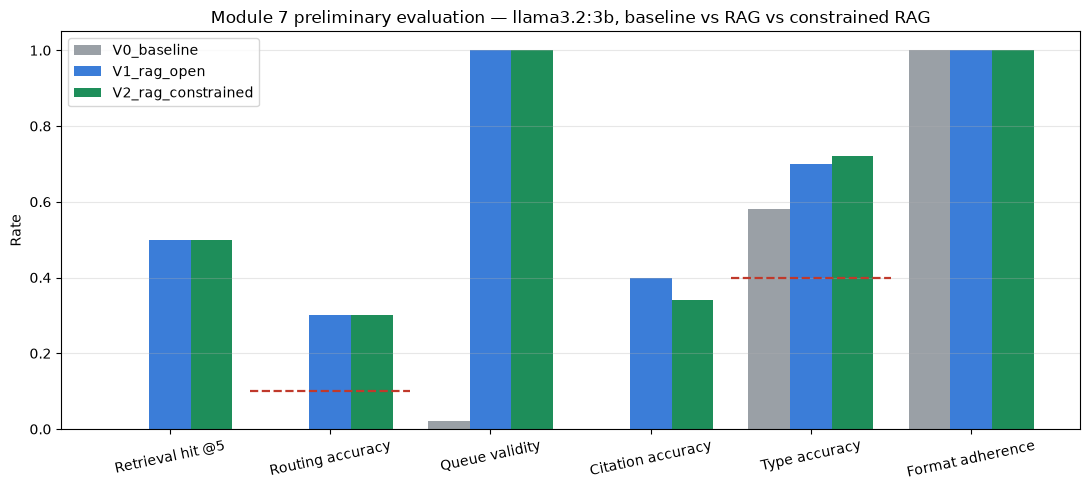

Saved: /Users/juampa/Documents/AtlantisUniversity/Master/MAI600/finalProject/images/evaluation_chart.png


In [17]:
# ============================================================
# 8D. Evaluation chart
# ============================================================

metrics = ["retrieval_hit_rate", "routing_accuracy", "queue_validity",
           "citation_accuracy", "type_accuracy", "format_adherence"]
labels  = [f"Retrieval hit @{TOP_K}", "Routing accuracy", "Queue validity",
           "Citation accuracy", "Type accuracy", "Format adherence"]

x = np.arange(len(metrics))
width = 0.26

fig, ax = plt.subplots(figsize=(11, 5))
colors = {"V0_baseline": "#9aa0a6", "V1_rag_open": "#3b7dd8",
          "V2_rag_constrained": "#1e8e5a"}
plotted = summary[summary["version"] != "V_majority_class"]
for i, (_, row) in enumerate(plotted.iterrows()):
    ax.bar(x + (i - 1) * width, [row[m] for m in metrics], width,
           label=row["version"], color=colors.get(row["version"]))

# The trivial reference is a line, not a bar: it is a floor to clear, not a system.
triv = summary[summary["version"] == "V_majority_class"].iloc[0]
for j, m in enumerate(metrics):
    if m in triv and pd.notna(triv[m]) and m != "queue_validity":
        ax.hlines(triv[m], j - 0.5, j + 0.5, color="#c0392b", linestyle="--", linewidth=1.6,
                  label="majority-class floor" if j == 0 else None)

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=12)
ax.set_ylim(0, 1.05); ax.set_ylabel("Rate")
ax.set_title(f"Module 7 preliminary evaluation — {MODEL}, baseline vs RAG vs constrained RAG")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGES / "evaluation_chart.png", dpi=150)
plt.show()
print("Saved:", IMAGES / "evaluation_chart.png")

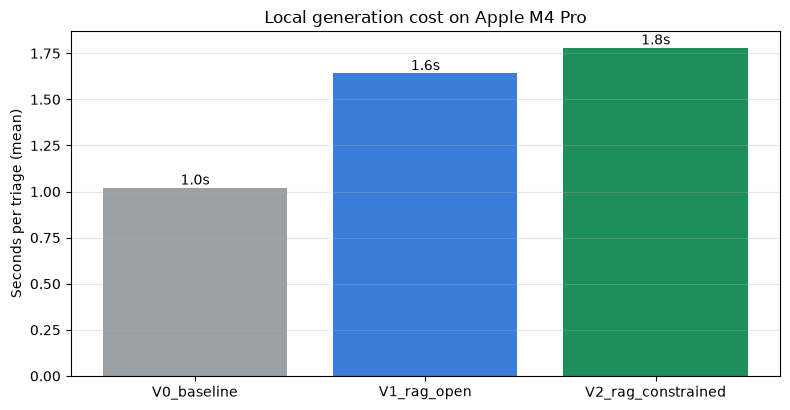

In [18]:
# ============================================================
# 8E. Response time chart
# ============================================================

rt = summary[summary["version"] != "V_majority_class"]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(rt["version"], rt["avg_response_time_s"], color=["#9aa0a6", "#3b7dd8", "#1e8e5a"])
for i, v in enumerate(rt["avg_response_time_s"]):
    ax.text(i, v, f"{v:.1f}s", ha="center", va="bottom")
ax.set_ylabel("Seconds per triage (mean)")
ax.set_title("Local generation cost on Apple M4 Pro")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGES / "response_time_chart.png", dpi=150)
plt.show()

## 9. Pipeline diagram

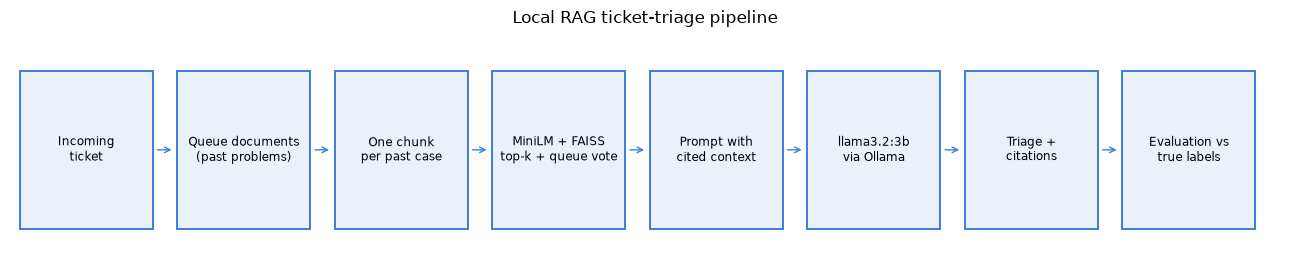

In [19]:
# ============================================================
# 9. Pipeline diagram
# ============================================================

fig, ax = plt.subplots(figsize=(13, 2.8))
ax.axis("off")

steps = ["Incoming\nticket", "Queue documents\n(past problems)", "One chunk\nper past case",
         "MiniLM + FAISS\ntop-k + queue vote", "Prompt with\ncited context", "llama3.2:3b\nvia Ollama",
         "Triage +\ncitations", "Evaluation vs\ntrue labels"]

for i, s in enumerate(steps):
    ax.add_patch(plt.Rectangle((i * 1.6, 0), 1.35, 1, facecolor="#eaf1fb",
                               edgecolor="#3b7dd8", linewidth=1.4))
    ax.text(i * 1.6 + 0.675, 0.5, s, ha="center", va="center", fontsize=8.5)
    if i < len(steps) - 1:
        ax.annotate("", xy=(i * 1.6 + 1.57, 0.5), xytext=(i * 1.6 + 1.37, 0.5),
                    arrowprops=dict(arrowstyle="->", color="#3b7dd8"))

ax.set_xlim(-0.1, len(steps) * 1.6); ax.set_ylim(-0.2, 1.2)
ax.set_title("Local RAG ticket-triage pipeline", pad=12)
plt.tight_layout()
plt.savefig(IMAGES / "pipeline_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Sample outputs (evidence)

In [20]:
# ============================================================
# 10. Side-by-side sample: baseline vs RAG
# ============================================================

tid = test_cases.loc[0, "test_id"]
case = ev[ev["test_id"] == tid]

print("=" * 78)
print("TICKET", tid)
print("=" * 78)
print(textwrap.fill(case.iloc[0]["question"][:600], 78))
print(f"\nTRUE LABELS -> queue: {case.iloc[0]['true_queue']} | "
      f"type: {case.iloc[0]['true_type']} | priority: {case.iloc[0]['true_priority']}")

for _, r in case.iterrows():
    print("\n" + "-" * 78)
    print(f"{r['version']}  ({r['model']}, {r['response_time_s']}s)")
    print("-" * 78)
    print(r["generated_answer"][:900])

TICKET T1
Troubleshooting Financial Firm's Data Analytics Tools. The financial firm's
data analytics tools are experiencing malfunctions, which might be due to
compatibility issues with recent software updates. Reinstalling the affected
applications and updating drivers resolved the issue previously. We require
your assistance to identify and fix the problem.

TRUE LABELS -> queue: Billing and Payments | type: Incident | priority: medium

------------------------------------------------------------------------------
V0_baseline  (llama3.2:3b, 4.35s)
------------------------------------------------------------------------------
Queue: Financial Tools Support
Type: Problem
Priority: Medium
Citations: NONE
Draft response: 
We've received your request for assistance with the malfunctions in your financial firm's data analytics tools. Our team will investigate the compatibility issues with recent software updates and work to resolve the problem. We'll be in touch with an estimated resolutio

## 11. Reports

The written deliverables are generated from the CSVs above by
`scripts/write_reports.py`, so the prose cannot drift away from the numbers.
Run it after this notebook finishes.


# Course module evidence

The sections above are the system. This one connects it back to the eight course modules,
producing the artefact the instructor guide names for each. Modules 6 and 8 are covered by
the pipeline and evaluation above and are cross-referenced rather than repeated.

Everything here runs on the local machine. The instructor's notebook installs Ollama into
a Colab VM and pulls a model over the network; this project serves Ollama natively, so
those steps are replaced by a check that the local server is already up.

| Module | Topic | Artefact |
|---|---|---|
| 1 | Tokenisation and context limits | `results/module1_token_budget.csv` |
| 2 | Sampling, temperature, reproducibility | `results/module2_sampling_comparison.csv` |
| 3 | Attention as evidence selection | `images/module3_evidence_map.png` |
| 4 | Prompting and structured output | `prompts/*.txt` |
| 5 | Local serving and benchmarking | `results/module5_local_slm_benchmark.csv` |
| 6 | Retrieval-augmented generation | `results/retrieved_chunks.csv` (above) |
| 7 | Fine-tuning readiness | `data/training_examples.jsonl`, `results/module7_rag_vs_finetuning_decision.csv` |
| 8 | Integration and evaluation | `results/summary_metrics.csv`, `images/evaluation_chart.png` (above) |

## Module 1 — Tokenisation and the context budget

Retrieval quality depends on text the encoder actually reads. `all-MiniLM-L6-v2` truncates
at 256 tokens, so any chunk longer than that is silently cut and the tail never reaches the
vector. Worth measuring rather than assuming.

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (285 > 256). Running this sequence through the model will result in indexing errors


encoder           all-MiniLM-L6-v2
token_limit                    256
chunks                        1782
mean_tokens                   75.4
median_tokens                   68
max_tokens                     346
chunks_truncated                 6
share_truncated             0.0034

6 of 1782 chunks exceed the 256-token limit (0.3%).
Truncation is therefore not a meaningful source of retrieval error here.


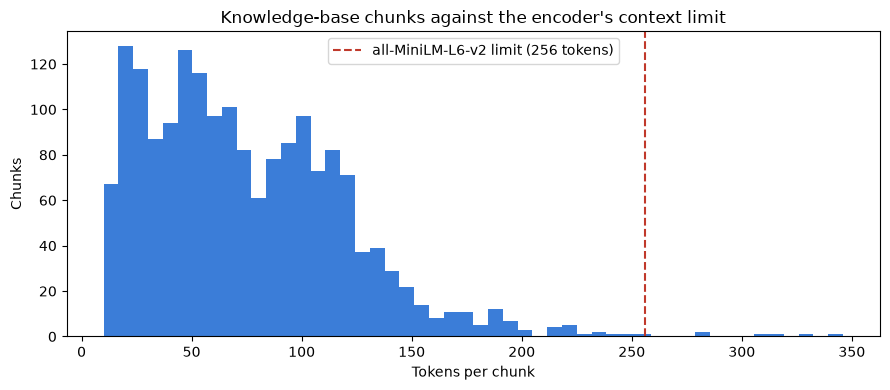

In [21]:
# ============================================================
# M1. Token budget of the knowledge base
# ============================================================

tokenizer = embedder.tokenizer
limit = embedder.max_seq_length

tok_len = np.array([len(tokenizer.encode(t)) for t in chunks_df["chunk_text"]])
over = int((tok_len > limit).sum())

budget = pd.DataFrame([{
    "encoder": EMBED_MODEL,
    "token_limit": limit,
    "chunks": len(tok_len),
    "mean_tokens": round(float(tok_len.mean()), 1),
    "median_tokens": int(np.median(tok_len)),
    "max_tokens": int(tok_len.max()),
    "chunks_truncated": over,
    "share_truncated": round(over / len(tok_len), 4),
}])
budget.to_csv(RESULTS / "module1_token_budget.csv", index=False)

print(budget.T.to_string(header=False))
print(f"\n{over} of {len(tok_len)} chunks exceed the {limit}-token limit "
      f"({over / len(tok_len):.1%}).")
print("Truncation is therefore not a meaningful source of retrieval error here.")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(tok_len, bins=50, color="#3b7dd8")
ax.axvline(limit, color="#c0392b", linestyle="--",
           label=f"{EMBED_MODEL} limit ({limit} tokens)")
ax.set_xlabel("Tokens per chunk"); ax.set_ylabel("Chunks")
ax.set_title("Knowledge-base chunks against the encoder's context limit")
ax.legend(); plt.tight_layout()
plt.savefig(IMAGES / "module1_token_budget.png", dpi=150)
plt.show()

## Module 2 — Sampling, temperature and reproducibility

The system runs at temperature 0.2. This measures what that choice buys by asking the same
question repeatedly at four settings and checking whether the answer holds still. For a
triage tool, an answer that changes between runs is a problem regardless of accuracy: two
agents looking at the same ticket would see different recommendations.

In [22]:
# ============================================================
# M2. Same prompt, four temperatures, three runs each
# ============================================================

probe_row = test_cases.iloc[0]
probe_retrieved = retrieve_chunks(probe_row["question"])
probe_prompt = build_constrained_prompt(
    probe_row["question"], probe_retrieved, queue_vote(probe_retrieved))

# Six runs per setting. Three was not enough to tell determinism from luck: at three
# samples a genuinely random setting can repeat itself and look stable.
RUNS = 6
rows = []
for temp in (0.0, 0.2, 0.7, 1.0):
    for run in range(1, RUNS + 1):
        text, secs = ask_ollama(probe_prompt, MODEL, temperature=temp)
        parsed = parse_triage(text)
        rows.append({"temperature": temp, "run": run,
                     "queue": parsed["pred_queue"] or parsed["pred_queue_raw"],
                     "type": parsed["pred_type"], "priority": parsed["pred_priority"],
                     "chars": len(text), "seconds": round(secs, 2)})

sampling = pd.DataFrame(rows)
sampling.to_csv(RESULTS / "module2_sampling_comparison.csv", index=False)

stability = (sampling.groupby("temperature")
                     .agg(distinct_queues=("queue", "nunique"),
                          distinct_types=("type", "nunique"),
                          distinct_priorities=("priority", "nunique"),
                          mean_chars=("chars", "mean"),
                          mean_seconds=("seconds", "mean"))
                     .reset_index())

print(f"Ticket {probe_row['test_id']} | true queue: {probe_row['true_queue']}\n")
print(f"Stability across {RUNS} runs at each setting:")
print(stability.to_string(index=False))
print()
print("The system runs at 0.2. If reproducibility matters more than variety -- and for")
print("triage it does, since two agents should not see different recommendations for")
print("the same ticket -- 0.0 is the defensible setting.")
print("\nA triage suggestion that changes between runs is a problem on its own: two")
print("agents reading the same ticket would be shown different recommendations.")

Ticket T1 | true queue: Billing and Payments

Stability across 6 runs at each setting:
 temperature  distinct_queues  distinct_types  distinct_priorities  mean_chars  mean_seconds
         0.0                1               1                    1  444.000000      0.961667
         0.2                1               1                    1  391.833333      0.856667
         0.7                2               2                    2  392.166667      0.838333
         1.0                2               2                    2  376.666667      0.838333

The system runs at 0.2. If reproducibility matters more than variety -- and for
triage it does, since two agents should not see different recommendations for
the same ticket -- 0.0 is the defensible setting.

A triage suggestion that changes between runs is a problem on its own: two
agents reading the same ticket would be shown different recommendations.


## Module 3 — Attention as evidence selection

Retrieval scores are the practical form of the question attention answers: which parts of
the available text should inform this output. Plotting them per candidate makes visible
whether the correct source won, and by how much.

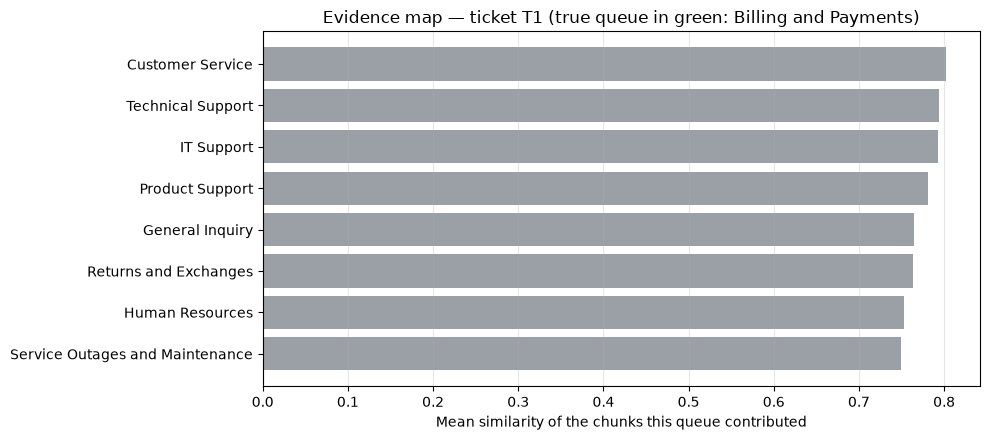

 rank         chunk_id  doc_id                           title    score  is_expected_source
    1  DOC-002-CASE-94 DOC-002                Customer Service 0.802025                   0
    2 DOC-006-CASE-126 DOC-006                 Product Support 0.801605                   0
    3  DOC-010-CASE-23 DOC-010               Technical Support 0.794324                   0
    4  DOC-005-CASE-43 DOC-005                      IT Support 0.792749                   0
    5   DOC-003-CASE-3 DOC-003                 General Inquiry 0.771337                   0
    6  DOC-007-CASE-57 DOC-007           Returns and Exchanges 0.763046                   0
    7 DOC-006-CASE-151 DOC-006                 Product Support 0.761679                   0
    8  DOC-003-CASE-49 DOC-003                 General Inquiry 0.758448                   0
    9  DOC-004-CASE-18 DOC-004                 Human Resources 0.753077                   0
   10  DOC-009-CASE-16 DOC-009 Service Outages and Maintenance 0.749074         

In [23]:
# ============================================================
# M3. Evidence map for one retrieved case
# ============================================================

emap_row = test_cases.iloc[0]
emap = retrieve_chunks(emap_row["question"], top_k=10)
emap_vote = queue_vote(emap)

emap_out = emap[["rank", "chunk_id", "doc_id", "title", "score"]].copy()
emap_out["is_expected_source"] = (emap_out["doc_id"] == emap_row["expected_source"]).astype(int)
emap_out.to_csv(RESULTS / "module3_evidence_map.csv", index=False)

colors = ["#1e8e5a" if q == emap_row["true_queue"] else "#9aa0a6"
          for q in emap_vote["queue"]]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(emap_vote["queue"][::-1], emap_vote["score"][::-1], color=colors[::-1])
ax.set_xlabel("Mean similarity of the chunks this queue contributed")
ax.set_title(f"Evidence map — ticket {emap_row['test_id']} "
             f"(true queue in green: {emap_row['true_queue']})")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGES / "module3_evidence_map.png", dpi=150, bbox_inches="tight")
plt.show()

print(emap_out.to_string(index=False))
print("\nWhen the correct source does not top this chart, no prompt downstream can")
print("recover it. That is where 71% of this system's routing errors originate.")

## Module 4 — Prompting and structured output

Both prompt templates are written to `prompts/` so they can be read and diffed without
running the notebook. The difference between them is the whole of the V0-to-V2 comparison.

In [24]:
# ============================================================
# M4. Export the prompt templates
# ============================================================

PROMPTS = ROOT / "prompts"
PROMPTS.mkdir(exist_ok=True)

sample_row = test_cases.iloc[0]
sample_retrieved = retrieve_chunks(sample_row["question"])

(PROMPTS / "baseline_prompt_template.txt").write_text(
    build_baseline_prompt("{{TICKET_SUBJECT_AND_BODY}}"), encoding="utf-8")

(PROMPTS / "improved_rag_prompt_template.txt").write_text(
    build_constrained_prompt("{{TICKET_SUBJECT_AND_BODY}}", sample_retrieved,
                             queue_vote(sample_retrieved)), encoding="utf-8")

(PROMPTS / "README.md").write_text(
    "# Prompt templates\n\n"
    "`baseline_prompt_template.txt` is the V0 prompt: no retrieved context, and no list\n"
    "of valid queues. Withholding the queue names is deliberate. Knowing which queues an\n"
    "organisation operates is exactly the local knowledge retrieval is meant to supply,\n"
    "so handing it to the baseline would hide the effect being measured.\n\n"
    "`improved_rag_prompt_template.txt` is the V2 prompt, shown with a real retrieval\n"
    "filled in. It adds the retrieved cases with their queue, type and priority labels,\n"
    "a ranked candidate list, and the rule that the queue must be chosen from that list.\n\n"
    "The ticket text is replaced by `{{TICKET_SUBJECT_AND_BODY}}` in both.\n",
    encoding="utf-8")

for f in sorted(PROMPTS.glob("*")):
    print(f"{f.name:<36} {f.stat().st_size:>6} bytes")

README.md                               658 bytes
baseline_prompt_template.txt            404 bytes
improved_rag_prompt_template.txt       5438 bytes


## Module 5 — Local serving benchmark

What local inference actually costs, recorded per generation rather than asserted.

In [25]:
# ============================================================
# M5. Benchmark the local model
# ============================================================

bench = []
for _, r in test_cases.head(10).iterrows():
    ret = retrieve_chunks(r["question"])
    prompt = build_constrained_prompt(r["question"], ret, queue_vote(ret))
    text, secs = ask_ollama(prompt, MODEL)
    n_out = len(tokenizer.encode(text))
    bench.append({
        "test_id": r["test_id"], "model": MODEL, "runtime": "Ollama (native)",
        "hardware": "Apple M4 Pro, 48 GB unified memory",
        "temperature": 0.2, "top_p": 0.8,
        "prompt_tokens": len(tokenizer.encode(prompt)),
        "output_tokens": n_out,
        "output_chars": len(text),
        "seconds": round(secs, 2),
        "tokens_per_second": round(n_out / secs, 1) if secs else None,
    })

benchmark = pd.DataFrame(bench)
benchmark.to_csv(RESULTS / "module5_local_slm_benchmark.csv", index=False)

print(benchmark[["test_id", "prompt_tokens", "output_tokens", "seconds",
                 "tokens_per_second"]].to_string(index=False))
print(f"\nmean {benchmark.seconds.mean():.2f}s per triage, "
      f"{benchmark.tokens_per_second.mean():.1f} output tokens/s")
print(f"prompt length {benchmark.prompt_tokens.mean():.0f} tokens on average -- well")
print(f"inside the model's context window, so retrieval depth is not limited by it.")

test_id  prompt_tokens  output_tokens  seconds  tokens_per_second
     T1           1168             93     0.98               95.2
     T2           1205             78     1.00               78.2
     T3           1133            109     1.20               91.1
     T4           1089            103     1.17               87.8
     T5            810            101     1.09               93.0
     T6           1157             75     0.92               81.5
     T7           1052             69     0.90               76.5
     T8           1092            101     1.13               89.4
     T9           1094             68     0.86               79.4
    T10            939             59     0.68               86.4

mean 0.99s per triage, 85.8 output tokens/s
prompt length 1074 tokens on average -- well
inside the model's context window, so retrieval depth is not limited by it.


## Module 7 — RAG or fine-tuning

The decision is recorded per field rather than for the system as a whole, because the
evidence points different ways for different fields.

In [26]:
# ============================================================
# M7. RAG vs fine-tuning, decided per output field
# ============================================================

s_ = summary.set_index("version")
decision = pd.DataFrame([
    {"field": "Queue",
     "measured": f"retrieval {s_.loc['V0_baseline'].routing_accuracy:.2f} -> "
                 f"{s_.loc['V2_rag_constrained'].routing_accuracy:.2f}, p = 0.0001",
     "rag_fit": "High", "finetuning_fit": "Low",
     "decision": "RAG",
     "why": "The knowledge missing from the baseline is the list of queues this "
            "organisation runs. Those change when the support team reorganises, and "
            "weights encoding them go stale. Retrieval also produces the citations this "
            "use case needs."},
    {"field": "Type",
     "measured": f"floor {s_.loc['V_majority_class'].type_accuracy:.2f}, "
                 f"baseline {s_.loc['V0_baseline'].type_accuracy:.2f}, "
                 f"RAG {s_.loc['V2_rag_constrained'].type_accuracy:.2f}",
     "rag_fit": "Low", "finetuning_fit": "High",
     "decision": "Fine-tuning candidate",
     "why": "A fixed four-way taxonomy that does not change. Retrieval barely moves it: "
            "passing the retrieved cases' type labels into the prompt changed the score "
            "by nothing. This is repeated judgement, which is what adapters teach."},
    {"field": "Priority",
     "measured": f"floor {s_.loc['V_majority_class'].priority_accuracy:.2f}, "
                 f"RAG {s_.loc['V2_rag_constrained'].priority_accuracy:.2f}",
     "rag_fit": "Low", "finetuning_fit": "Low",
     "decision": "Neither",
     "why": "Urgency depends on contract tier, SLA and blast radius. None of it is in the "
            "ticket text, so no amount of retrieval or adaptation can recover it. This "
            "needs a different input, not a different method."},
    {"field": "Draft response",
     "measured": f"format adherence {s_.loc['V2_rag_constrained'].format_adherence:.2f}",
     "rag_fit": "High", "finetuning_fit": "Medium",
     "decision": "RAG",
     "why": "The reply has to reflect how this team actually resolves the issue, which is "
            "what the retrieved resolutions supply. Format already holds at 1.00, so "
            "there is nothing for an adapter to fix."},
])
decision.to_csv(RESULTS / "module7_rag_vs_finetuning_decision.csv", index=False)

print(decision[["field", "decision", "rag_fit", "finetuning_fit"]].to_string(index=False))
print(f"\nTraining examples for the Type field are prepared in "
      f"data/training_examples.jsonl.")
print("No adapter was trained, and no claim is made about what one would achieve.")

         field              decision rag_fit finetuning_fit
         Queue                   RAG    High            Low
          Type Fine-tuning candidate     Low           High
      Priority               Neither     Low            Low
Draft response                   RAG    High         Medium

Training examples for the Type field are prepared in data/training_examples.jsonl.
No adapter was trained, and no claim is made about what one would achieve.


## Module summary

Each artefact above is referenced from the written deliverables: `results.md` for the
evaluation, `MAI600_FinalPrj_Arnedo.pdf` for the argument, and `README.md` for the file map.